# Food to Recipe Generation using Qwen2.5-VL-3B

## Project Overview

This notebook implements a deep learning system that generates cooking recipes from images of food using **Qwen2.5-VL-3B-Instruct** as a native vision-language model.

### Key Features:
- ✅ **Native Vision-Language Model**: Qwen2.5-VL handles both vision and language in one model
- ✅ **Instruction-Tuned**: Better at following prompts and generating structured recipes
- ✅ **Multi-GPU Support**: Optimized for training on multiple GPUs with DeepSpeed ZeRO
- ✅ **Memory Efficient**: Gradient checkpointing and FP16 precision for efficient training

### Approach
1. Load and preprocess food image-recipe dataset
2. Fine-tune Qwen2.5-VL-3B on image-recipe pairs
3. Generate recipes from food images
4. Evaluate recipe quality using various metrics

## 1. Installation and Imports

In [ ]:
# CRITICAL: Set single GPU BEFORE importing torch
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Only use GPU 0
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Import necessary libraries
import pandas as pd
import numpy as np
import zipfile
import re
import random
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Metrics libraries
try:
    from rouge_score import rouge_scorer
    ROUGE_AVAILABLE = True
except ImportError:
    print("Installing rouge-score...")
    import subprocess
    subprocess.check_call(["pip", "install", "-q", "rouge-score"])
    from rouge_score import rouge_scorer
    ROUGE_AVAILABLE = True

try:
    import sacrebleu
    BLEU_AVAILABLE = True
except ImportError:
    print("Installing sacrebleu...")
    import subprocess
    subprocess.check_call(["pip", "install", "-q", "sacrebleu"])
    import sacrebleu
    BLEU_AVAILABLE = True

# Hugging Face Libraries
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    TrainingArguments,
    Trainer
)
from qwen_vl_utils import process_vision_info

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully!")
print(f"  CUDA_VISIBLE_DEVICES = {os.environ.get('CUDA_VISIBLE_DEVICES', 'not set')}")
print(f"  PyTorch sees {torch.cuda.device_count()} GPU(s)")

✓ Libraries imported successfully!
  CUDA_VISIBLE_DEVICES = 0
  PyTorch sees 1 GPU(s)


## 2. Device Configuration

In [ ]:
# Configure device - should only see 1 GPU now
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    device = torch.device("cuda:0")
    print(f"Found {num_gpus} GPU(s) visible to PyTorch")
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        gpu_memory = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  GPU {i}: {gpu_name} ({gpu_memory:.1f} GB)")
    
    # Enable optimizations
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print("✓ CUDA optimizations enabled")
else:
    device = torch.device("cpu")
    num_gpus = 0
    print("⚠️ Using CPU (No GPU available)")

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")

Found 1 GPU(s) visible to PyTorch
  GPU 0: NVIDIA GeForce RTX 3090 (25.3 GB)
✓ CUDA optimizations enabled

PyTorch version: 2.9.0+cu128
CUDA available: True
CUDA version: 12.8


## 3. Dataset Loading

In [ ]:
# Extract dataset if zipped
zip_file = "Food Ingredients and Recipe Dataset with Image Name Mapping.csv.zip"
target_csv = "Food Ingredients and Recipe Dataset with Image Name Mapping.csv"

if os.path.exists(zip_file) and not os.path.exists(target_csv):
    print(f"Extracting {zip_file}...")
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(".")
    print(f"✓ Extracted successfully!")

# Load dataset
if os.path.exists(target_csv):
    main_dataset = pd.read_csv(target_csv)
    print(f"✓ Loaded {len(main_dataset)} recipes")
    print(f"\nDataset columns: {list(main_dataset.columns)}")
    print(f"\nSample recipe:")
    print(f"  Title: {main_dataset.iloc[0]['Title']}")
else:
    raise FileNotFoundError(f"Dataset '{target_csv}' not found!")

✓ Loaded 13501 recipes

Dataset columns: ['Unnamed: 0', 'Title', 'Ingredients', 'Instructions', 'Image_Name', 'Cleaned_Ingredients']

Sample recipe:
  Title: Miso-Butter Roast Chicken With Acorn Squash Panzanella


## 4. Image Path Resolution

In [ ]:
def find_image_file(image_name, search_dirs=['food_images/Food Images', 'food_images', '.']):
    """Find image file by name in common directories."""
    extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
    
    for directory in search_dirs:
        if not os.path.exists(directory):
            continue
        
        for ext in extensions:
            path = os.path.join(directory, image_name + ext)
            if os.path.exists(path) and os.path.isfile(path):
                return path
    
    return None

# Process dataset and find images
processed_data = []

print("Processing dataset and finding images...")
for idx, row in main_dataset.iterrows():
    image_name = row['Image_Name']
    image_path = find_image_file(image_name)
    
    if image_path is None:
        continue
    
    # Format recipe for Qwen
    title = row['Title']
    ingredients = row['Ingredients']
    instructions = row['Instructions']
    
    recipe_output = f"""RECIPE: {title}

INGREDIENTS:
{ingredients}

INSTRUCTIONS:
{instructions}"""
    
    processed_data.append({
        'image_path': image_path,
        'title': title,
        'ingredients': ingredients,
        'instructions': instructions,
        'recipe': recipe_output
    })

print(f"✓ Processed {len(processed_data)} samples with valid images out of {len(main_dataset)} total")
if processed_data:
    print(f"\nSample: {processed_data[0]['title']}")
    print(f"  Image: {processed_data[0]['image_path']}")

Processing dataset and finding images...
✓ Processed 13471 samples with valid images out of 13501 total

Sample: Miso-Butter Roast Chicken With Acorn Squash Panzanella
  Image: food_images/Food Images/miso-butter-roast-chicken-acorn-squash-panzanella.jpg


## 5. Load Qwen2.5-VL-3B Model

In [ ]:
# Load Qwen2.5-VL-3B-Instruct model with LoRA for memory-efficient training
print("Loading Qwen2.5-VL-3B-Instruct with LoRA...")
print("This may take a few minutes...")

model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

# Clear GPU cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Install peft if not available
try:
    from peft import LoraConfig, get_peft_model
    print("✓ PEFT library available")
except ImportError:
    print("Installing PEFT for LoRA support...")
    import subprocess
    subprocess.check_call(["pip", "install", "-q", "peft"])
    from peft import LoraConfig, get_peft_model

# Load base model - use device_map=None and manually move to GPU
# This avoids accelerate's device_map which can cause multi-GPU issues
qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
    device_map=None,  # Don't use device_map
)

# Manually move to GPU 0
qwen_model = qwen_model.to("cuda:0")

# Load processor
qwen_processor = AutoProcessor.from_pretrained(model_name)

# Configure LoRA - Enhanced for better learning
lora_config = LoraConfig(
    r=16,  # Increased rank for better adaptation
    lora_alpha=32,  # Scale with rank
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # More attention layers
    lora_dropout=0.1,  # Slightly higher dropout for regularization
    bias="none",
    task_type="CAUSAL_LM",
)

# Apply LoRA
qwen_model = get_peft_model(qwen_model, lora_config)

# Enable gradient checkpointing
qwen_model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})

# Print info
total_params = sum(p.numel() for p in qwen_model.parameters())
trainable_params = sum(p.numel() for p in qwen_model.parameters() if p.requires_grad)

print("✓ Qwen2.5-VL with LoRA loaded!")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)")
print(f"  Model device: {next(qwen_model.parameters()).device}")

# Clear cache again
torch.cuda.empty_cache()
allocated = torch.cuda.memory_allocated(0) / 1e9
print(f"  GPU memory used: {allocated:.2f} GB")

Loading Qwen2.5-VL-3B-Instruct with LoRA...
This may take a few minutes...
✓ PEFT library available


Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.56s/it]


✓ Qwen2.5-VL with LoRA loaded!
  Total parameters: 3,761,995,776
  Trainable parameters: 7,372,800 (0.20%)
  Model device: cuda:0
  GPU memory used: 15.09 GB


## 6. Dataset Class Definition

In [ ]:
class QwenRecipeDataset(Dataset):
    """Dataset class for Qwen recipe generation - memory optimized."""
    
    def __init__(self, data, processor, max_length=1024):  # Reduced from 2048
        self.data = data
        self.processor = processor
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        
        # Load and resize image to reduce memory
        image = Image.open(item['image_path']).convert('RGB')
        # Resize large images to save memory
        max_size = 448  # Reduced from default
        if max(image.size) > max_size:
            ratio = max_size / max(image.size)
            new_size = (int(image.size[0] * ratio), int(image.size[1] * ratio))
            image = image.resize(new_size, Image.LANCZOS)
        
        # Create prompt
        prompt_text = "Generate a cooking recipe from this food image."
        
        # Truncate recipe if too long
        recipe = item['recipe'][:1500]  # Limit recipe length
        
        # Create messages for Qwen
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": prompt_text}
                ]
            },
            {
                "role": "assistant",
                "content": recipe
            }
        ]
        
        # Apply chat template
        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        
        # Process inputs
        inputs = self.processor(
            text=[text],
            images=[image],
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        
        # Move to CPU and remove batch dimension
        result = {}
        for k, v in inputs.items():
            if k == 'image_grid_thw':
                if isinstance(v, torch.Tensor):
                    v_np = v.cpu().numpy() if v.is_cuda else v.numpy()
                elif hasattr(v, '__array__'):
                    v_np = np.array(v)
                else:
                    v_np = v
                
                if isinstance(v_np, np.ndarray):
                    if v_np.ndim == 2 and v_np.shape[0] == 1:
                        result[k] = tuple(v_np[0].astype(int))
                    elif v_np.ndim == 1 and v_np.shape[0] == 3:
                        result[k] = tuple(v_np.astype(int))
                    else:
                        result[k] = tuple(v_np.flatten()[:3].astype(int)) if v_np.size >= 3 else (1, 1, 1)
                elif isinstance(v_np, (list, tuple)):
                    if len(v_np) == 1 and isinstance(v_np[0], (list, tuple, np.ndarray)):
                        result[k] = tuple(v_np[0][:3]) if len(v_np[0]) >= 3 else (1, 1, 1)
                    elif len(v_np) >= 3:
                        result[k] = tuple(v_np[:3])
                    else:
                        result[k] = (1, 1, 1)
                else:
                    result[k] = (1, 1, 1)
            elif isinstance(v, torch.Tensor):
                if v.dim() > 0 and v.shape[0] == 1:
                    result[k] = v.squeeze(0)
                else:
                    result[k] = v
            else:
                result[k] = v
        
        # Ensure image_grid_thw exists
        if 'image_grid_thw' not in result:
            result['image_grid_thw'] = (1, 1, 1)
        else:
            grid_thw = result['image_grid_thw']
            if not isinstance(grid_thw, tuple) or len(grid_thw) != 3:
                result['image_grid_thw'] = (1, 1, 1)
            elif any(not isinstance(x, (int, np.integer)) or x <= 0 for x in grid_thw):
                result['image_grid_thw'] = (1, 1, 1)
            else:
                result['image_grid_thw'] = tuple(int(max(1, x)) for x in grid_thw)
        
        # Labels for training
        labels = result['input_ids'].clone()
        result['labels'] = labels
        
        return result

## 7. Create Train/Test Split

In [ ]:
# Create dataset splits
random.seed(42)
random.shuffle(processed_data)

# Increase dataset size for better learning
max_samples = 1000  # Increased from 600
dataset_subset = processed_data[:max_samples]

train_size = int(0.9 * len(dataset_subset))  # 90% for training
test_size = len(dataset_subset) - train_size

train_data = dataset_subset[:train_size]
test_data = dataset_subset[train_size:]

print(f"Dataset split:")
print(f"  Training samples: {len(train_data)}")
print(f"  Test samples: {len(test_data)}")

# Create PyTorch datasets
train_dataset = QwenRecipeDataset(train_data, qwen_processor)
test_dataset = QwenRecipeDataset(test_data, qwen_processor)

Dataset split:
  Training samples: 900
  Test samples: 100


## 8. Training Configuration

In [ ]:
# Training arguments optimized for better metrics
per_device_batch = 1
gradient_accum = 8

effective_batch_size = per_device_batch * gradient_accum

training_args = TrainingArguments(
    output_dir="./qwen_recipe_output",
    num_train_epochs=5,  # Increased from 3
    per_device_train_batch_size=per_device_batch,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=gradient_accum,
    learning_rate=1e-4,  # Lower LR for stability
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    max_grad_norm=1.0,
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    fp16=True,
    bf16=False,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    remove_unused_columns=False,
    report_to="none",
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="adamw_torch",
    weight_decay=0.01,
    dataloader_drop_last=True,
    local_rank=-1,
    ddp_find_unused_parameters=False,
)

print("✓ Training configuration ready!")
print(f"  Epochs: 5")
print(f"  Batch size: {per_device_batch}")
print(f"  Gradient accumulation: {gradient_accum}")
print(f"  Effective batch size: {effective_batch_size}")
print(f"  Learning rate: 1e-4")

✓ Training configuration ready!
  Epochs: 5
  Batch size: 1
  Gradient accumulation: 8
  Effective batch size: 8
  Learning rate: 1e-4


## 9. Optional: DeepSpeed Configuration (for Multi-GPU)

**Note**: If you see linker errors about `-laio` when importing DeepSpeed, these are **non-critical warnings**. DeepSpeed will work fine without the `libaio` library - you'll just miss some optional I/O optimizations. To install the library (optional):
```bash
sudo apt-get install libaio-dev
```

In [ ]:
# DeepSpeed is disabled - using single GPU training for memory efficiency
USE_DEEPSPEED = False

print("⚠️ DeepSpeed disabled - using single GPU training")
print("  This avoids multi-GPU gradient synchronization OOM errors")
print("  Training will use GPU 0 with gradient checkpointing for memory efficiency")

⚠️ DeepSpeed disabled - using single GPU training
  This avoids multi-GPU gradient synchronization OOM errors
  Training will use GPU 0 with gradient checkpointing for memory efficiency


## 10. Data Collator

In [ ]:
from typing import Dict, List

class QwenDataCollator:
    """Custom data collator for Qwen multimodal inputs."""
    
    def __init__(self, processor):
        self.processor = processor
    
    def __call__(self, features: List[Dict]) -> Dict[str, torch.Tensor]:
        batch = {}
        
        # Stack image inputs
        if 'pixel_values' in features[0]:
            batch['pixel_values'] = torch.stack([f['pixel_values'] for f in features])
        
        if 'pixel_values_vl' in features[0]:
            batch['pixel_values_vl'] = torch.stack([f['pixel_values_vl'] for f in features])
        
        # CRITICAL: Preserve image_grid_thw metadata
        # image_grid_thw should be a tensor of shape (batch_size, 3) for the batch
        # Each feature has image_grid_thw as a tuple (t, h, w) for its single image
        if 'image_grid_thw' in features[0]:
            image_grid_thw_list = []
            for f in features:
                grid_thw = f.get('image_grid_thw', None)
                if grid_thw is not None:
                    # Ensure it's a tuple of 3 positive integers
                    if isinstance(grid_thw, (list, tuple)):
                        if len(grid_thw) == 3 and all(isinstance(x, (int, np.integer)) for x in grid_thw):
                            # Validate all are positive
                            t, h, w = grid_thw
                            if t > 0 and h > 0 and w > 0:
                                image_grid_thw_list.append([int(t), int(h), int(w)])
                            else:
                                image_grid_thw_list.append([1, 1, 1])
                        else:
                            # Invalid format - use default
                            image_grid_thw_list.append([1, 1, 1])
                    else:
                        # Not a tuple/list - use default
                        image_grid_thw_list.append([1, 1, 1])
                else:
                    # Missing - use default
                    image_grid_thw_list.append([1, 1, 1])
            
            # Convert to tensor: shape (batch_size, 3)
            # CRITICAL: Must be LongTensor with positive integers
            batch['image_grid_thw'] = torch.tensor(image_grid_thw_list, dtype=torch.long)
        
        # Handle input_ids with padding
        if 'input_ids' in features[0]:
            max_length = max(len(f['input_ids']) for f in features)
            max_length = min(max_length, 2048)  # Cap at 2048
            
            pad_token_id = self.processor.tokenizer.pad_token_id
            if pad_token_id is None:
                pad_token_id = self.processor.tokenizer.eos_token_id
            
            input_ids = []
            attention_mask = []
            labels = []
            
            for f in features:
                ids = f['input_ids'][:max_length]
                padding_length = max_length - len(ids)
                
                ids = torch.cat([ids, torch.full((padding_length,), pad_token_id, dtype=ids.dtype)])
                mask = torch.cat([torch.ones(len(f['input_ids'][:max_length]), dtype=torch.bool),
                                torch.zeros(padding_length, dtype=torch.bool)])
                
                label = f['labels'][:max_length] if 'labels' in f else ids.clone()
                # Mask padding tokens in labels
                label_padding = torch.full((padding_length,), -100, dtype=label.dtype)
                label = torch.cat([label, label_padding])
                
                input_ids.append(ids)
                attention_mask.append(mask)
                labels.append(label)
            
            batch['input_ids'] = torch.stack(input_ids)
            batch['attention_mask'] = torch.stack(attention_mask)
            batch['labels'] = torch.stack(labels)
        
        return batch

data_collator = QwenDataCollator(qwen_processor)
print("✓ Data collator created")

✓ Data collator created


## 11. Clear GPU Memory Before Training


In [ ]:
# Clear GPU memory before training (Single GPU mode)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(0)
    torch.cuda.synchronize(0)
    print("✓ GPU memory cleared")
    
    # Print current memory usage
    allocated = torch.cuda.memory_allocated(0) / 1e9
    reserved = torch.cuda.memory_reserved(0) / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU 0: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved, {total:.2f} GB total")
    
    # Verify model is on GPU
    model_device = next(qwen_model.parameters()).device
    print(f"  Model device: {model_device}")
    if model_device.type == 'cpu':
        print("  ⚠️ Moving model to GPU...")
        qwen_model = qwen_model.to(device)
        model_device = next(qwen_model.parameters()).device
        print(f"  ✓ Model now on {model_device}")


✓ GPU memory cleared
  GPU 0: 15.09 GB allocated, 15.10 GB reserved, 25.30 GB total
  Model device: cuda:0


## 10.5. Metrics Computation Functions


In [ ]:
# Install metrics libraries if needed
import subprocess
import sys

def install_if_missing(package, import_name=None):
    """Install package if not already installed."""
    if import_name is None:
        import_name = package
    try:
        __import__(import_name.replace('-', '_'))
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

# Install required packages
install_if_missing('rouge-score', 'rouge_score')
install_if_missing('sacrebleu')

# Now import them
from rouge_score import rouge_scorer
import sacrebleu

print("Metrics libraries loaded!")

# Function to extract ingredients and instructions from recipe text
def extract_recipe_sections(recipe_text):
    """Extract ingredients and instructions from recipe text."""
    recipe_lower = recipe_text.lower()
    
    # Try to find ingredients section
    ingredients = []
    if 'ingredients' in recipe_lower:
        try:
            ingredients_start = recipe_lower.find('ingredients')
            ingredients_end = recipe_lower.find('instructions', ingredients_start)
            if ingredients_end == -1:
                ingredients_end = recipe_lower.find('directions', ingredients_start)
            if ingredients_end == -1:
                ingredients_end = len(recipe_text)
            
            ingredients_section = recipe_text[ingredients_start:ingredients_end]
            # Extract lines with ingredients
            for line in ingredients_section.split('\n'):
                line = line.strip()
                if line and not line.lower().startswith('ingredients'):
                    # Remove markers like "-", ".", numbers
                    line = re.sub(r'^[-\d.\s]+', '', line)
                    if line:
                        ingredients.append(line)
        except:
            pass
    
    # Try to find instructions section
    instructions = []
    if 'instructions' in recipe_lower or 'directions' in recipe_lower:
        try:
            instr_start = recipe_lower.find('instructions')
            if instr_start == -1:
                instr_start = recipe_lower.find('directions')
            
            instructions_section = recipe_text[instr_start:]
            # Extract lines with instructions
            for line in instructions_section.split('\n'):
                line = line.strip()
                if line and not line.lower().startswith(('instructions', 'directions')):
                    # Remove markers
                    line = re.sub(r'^[-\d.\s]+', '', line)
                    if line:
                        instructions.append(line)
        except:
            pass
    
    return ingredients, instructions


def compute_f1_score(pred_items, gold_items):
    """Compute F1 score for sets of items (e.g., ingredients)."""
    if not pred_items and not gold_items:
        return 1.0
    if not pred_items or not gold_items:
        return 0.0
    
    # Convert to sets of words (case-insensitive)
    pred_words = set()
    gold_words = set()
    
    for item in pred_items:
        pred_words.update(word.lower() for word in item.split())
    for item in gold_items:
        gold_words.update(word.lower() for word in item.split())
    
    if not pred_words or not gold_words:
        return 0.0
    
    intersection = pred_words & gold_words
    if not intersection:
        return 0.0
    
    precision = len(intersection) / len(pred_words)
    recall = len(intersection) / len(gold_words)
    
    if precision + recall == 0:
        return 0.0
    
    f1 = 2 * (precision * recall) / (precision + recall)
    return f1


def compute_recipe_metrics(generated_text, ground_truth_text):
    """
    Compute ROUGE-L, BLEU, and F1 scores for recipe generation.
    
    Args:
        generated_text: Generated recipe text
        ground_truth_text: Ground truth recipe text
    
    Returns:
        dict with rouge_l, bleu, ingredient_f1, instruction_f1 scores
    """
    metrics = {}
    
    # ROUGE-L score
    try:
        rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
        rouge_scores = rouge.score(ground_truth_text, generated_text)
        metrics['rouge_l'] = rouge_scores['rougeL'].fmeasure
    except Exception as e:
        print(f"ROUGE-L error: {e}")
        metrics['rouge_l'] = 0.0
    
    # BLEU score
    try:
        bleu = sacrebleu.corpus_bleu(
            [generated_text], 
            [[ground_truth_text]],
            force=False,
            lowercase=True,
            tokenize='intl'
        )
        metrics['bleu'] = bleu.score / 100.0  # Normalize to 0-1
    except Exception as e:
        print(f"BLEU error: {e}")
        metrics['bleu'] = 0.0
    
    # F1 scores for ingredients and instructions
    gen_ingredients, gen_instructions = extract_recipe_sections(generated_text)
    gold_ingredients, gold_instructions = extract_recipe_sections(ground_truth_text)
    
    metrics['ingredient_f1'] = compute_f1_score(gen_ingredients, gold_ingredients)
    metrics['instruction_f1'] = compute_f1_score(gen_instructions, gold_instructions)
    
    return metrics


print("Metrics computation functions defined!")
print("  - ROUGE-L: Overall recipe similarity")
print("  - BLEU: N-gram overlap")
print("  - F1 (Ingredients): Ingredient overlap")
print("  - F1 (Instructions): Instruction overlap")

Metrics libraries loaded!
Metrics computation functions defined!
  - ROUGE-L: Overall recipe similarity
  - BLEU: N-gram overlap
  - F1 (Ingredients): Ingredient overlap
  - F1 (Instructions): Instruction overlap


## 11. Training

### 11.1 Run Training

In [ ]:
# Create trainer
trainer = Trainer(
    model=qwen_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
)

print("✓ Trainer created")
print("\nStarting training with LoRA...")
print("=" * 60)

# Train the model
trainer.train()

print("\n" + "=" * 60)
print("✓ Training complete!")

# Save LoRA adapter weights
final_model_dir = "./qwen_recipe_model_final"
qwen_model.save_pretrained(final_model_dir)
qwen_processor.save_pretrained(final_model_dir)
print(f"✓ LoRA adapter saved to {final_model_dir}")

# Store training history for later use
training_history = trainer.state.log_history if hasattr(trainer.state, 'log_history') else []
print(f"✓ Training history recorded ({len(training_history)} log entries)")

✓ Trainer created

Starting training with LoRA...


Step,Training Loss,Validation Loss
50,3.131200,2.878420
100,2.343000,2.325035
150,2.349800,2.298648
200,2.338300,2.285080
250,2.282000,2.276645
300,2.275100,2.271297
350,2.291700,2.268387
400,2.250000,2.265556
450,2.252200,2.263619
500,2.220400,2.263715



✓ Training complete!
✓ LoRA adapter saved to ./qwen_recipe_model_final
✓ Training history recorded (68 log entries)


### 11.2 Visualize Training Curves


Plotting training curves...


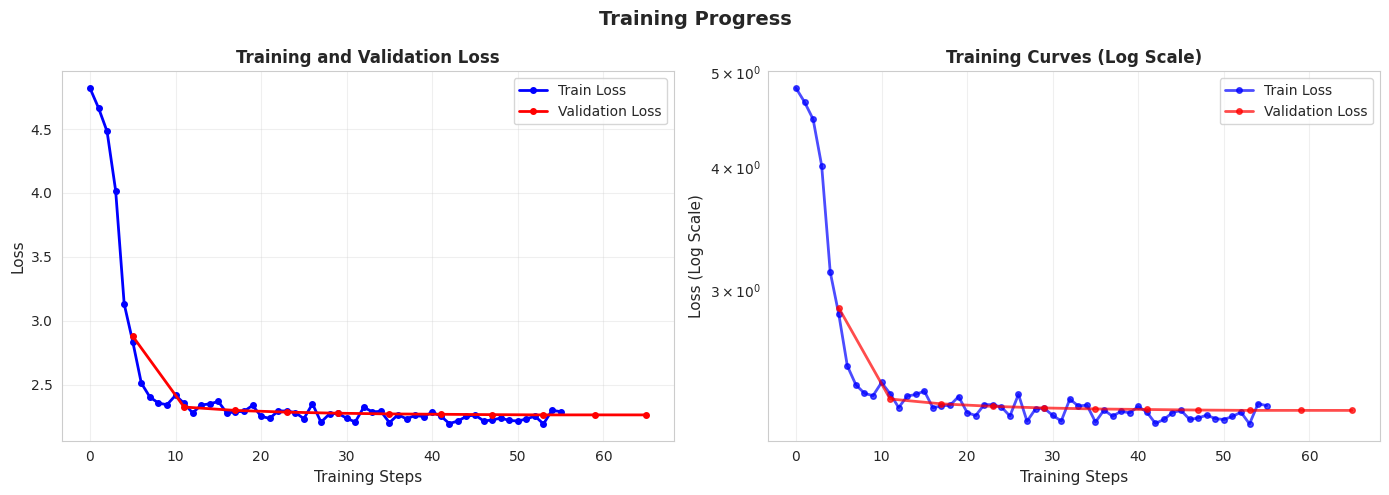


Final Train Loss: 2.2891
Final Validation Loss: 2.2635
✓ Training curves saved to 'training_curves.png'


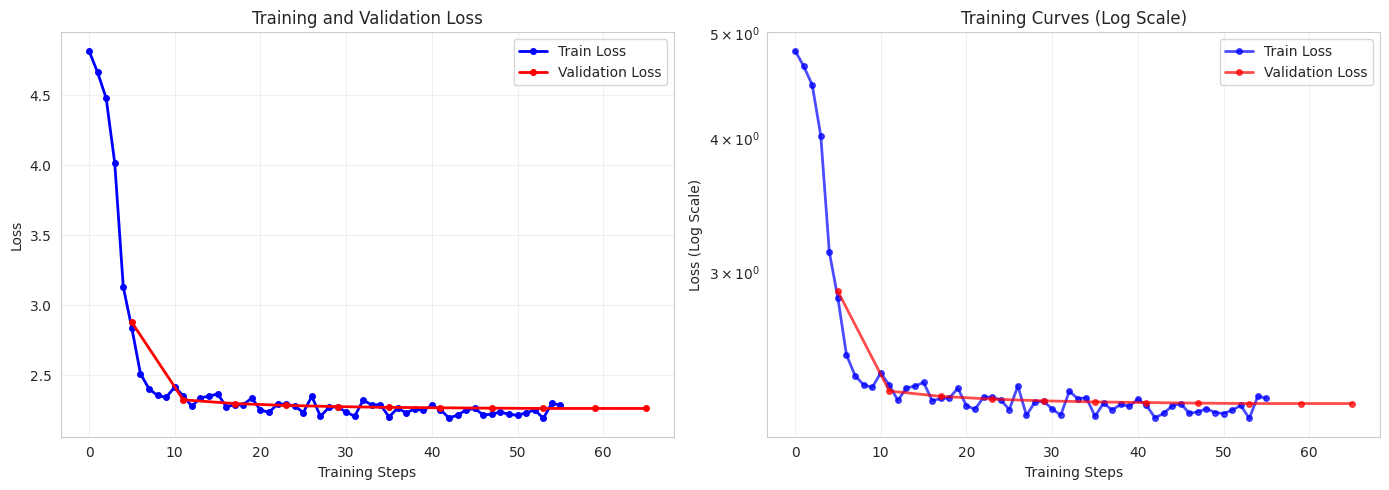

In [33]:
# Plot training curves from Trainer log history
if 'trainer' in globals() and hasattr(trainer, 'state') and hasattr(trainer.state, 'log_history'):
    log_history = trainer.state.log_history
    
    # Extract training and validation losses
    train_losses = [entry['loss'] for entry in log_history if 'loss' in entry and 'eval_loss' not in entry]
    eval_losses = [entry['eval_loss'] for entry in log_history if 'eval_loss' in entry]
    learning_rates = [entry['learning_rate'] for entry in log_history if 'learning_rate' in entry]
    
    if train_losses:
        print("Plotting training curves...")
        
        # Create figure with subplots
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Training Progress', fontsize=14, fontweight='bold')
        
        # Plot 1: Training and Validation Loss
        ax1 = axes[0]
        train_steps = range(len(train_losses))
        ax1.plot(train_steps, train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=4)
        
        if eval_losses:
            # Get step numbers for eval losses
            eval_steps = [i for i, entry in enumerate(log_history) if 'eval_loss' in entry]
            if len(eval_steps) == len(eval_losses):
                ax1.plot(eval_steps, eval_losses, 'r-o', label='Validation Loss', linewidth=2, markersize=4)
        
        ax1.set_xlabel('Training Steps', fontsize=11)
        ax1.set_ylabel('Loss', fontsize=11)
        ax1.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Training Loss (Log Scale)
        ax2 = axes[1]
        ax2.plot(train_steps, train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=4, alpha=0.7)
        
        if eval_losses and len(eval_steps) == len(eval_losses):
            ax2.plot(eval_steps, eval_losses, 'r-o', label='Validation Loss', linewidth=2, markersize=4, alpha=0.7)
        
        ax2.set_xlabel('Training Steps', fontsize=11)
        ax2.set_ylabel('Loss (Log Scale)', fontsize=11)
        ax2.set_title('Training Curves (Log Scale)', fontsize=12, fontweight='bold')
        ax2.set_yscale('log')
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print final losses
        print(f"\nFinal Train Loss: {train_losses[-1]:.4f}")
        if eval_losses:
            print(f"Final Validation Loss: {eval_losses[-1]:.4f}")
        
        # Check for overfitting
        if eval_losses and len(eval_losses) > 1:
            if eval_losses[-1] > eval_losses[-2]:
                print("⚠️  Warning: Validation loss increased - possible overfitting")
        
        # Save the plot
        plt.figure(figsize=(14, 5))
        plt.subplot(1, 2, 1)
        plt.plot(train_steps, train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=4)
        if eval_losses and len(eval_steps) == len(eval_losses):
            plt.plot(eval_steps, eval_losses, 'r-o', label='Validation Loss', linewidth=2, markersize=4)
        plt.xlabel('Training Steps')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.plot(train_steps, train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=4, alpha=0.7)
        if eval_losses and len(eval_steps) == len(eval_losses):
            plt.plot(eval_steps, eval_losses, 'r-o', label='Validation Loss', linewidth=2, markersize=4, alpha=0.7)
        plt.xlabel('Training Steps')
        plt.ylabel('Loss (Log Scale)')
        plt.title('Training Curves (Log Scale)')
        plt.yscale('log')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
        print("✓ Training curves saved to 'training_curves.png'")
        
    else:
        print("⚠️ No training loss data available in log history")
else:
    print("⚠️ No training history available")
    print("   Please run the training cell first (cell 26)")


In [34]:
## 11.4. Recipe Generation Function (Required for Evaluation)

def generate_recipe(image_path, model, processor, max_new_tokens=2048):
    """Generate a recipe from a food image."""
    
    # Load image
    image = Image.open(image_path).convert('RGB')
    
    # Create prompt
    prompt_text = "Generate a detailed cooking recipe from this food image. Include ingredients, instructions, cooking times, and temperatures."
    
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt_text}
            ]
        }
    ]
    
    # Process inputs
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )
    
    # Move to device
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Get token IDs
    pad_token_id = processor.tokenizer.pad_token_id or processor.tokenizer.eos_token_id
    eos_token_id = processor.tokenizer.eos_token_id
    
    # Generate
    model.eval()
    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=pad_token_id,
            eos_token_id=eos_token_id,
            repetition_penalty=1.1,
        )
    
    # Decode only the newly generated tokens
    input_length = inputs['input_ids'].shape[1]
    generated_tokens = generated_ids[0][input_length:]
    
    # Decode
    recipe = processor.decode(generated_tokens, skip_special_tokens=True)
    
    return {
        'recipe': recipe,
        'image_path': image_path
    }

print("✓ Recipe generation function defined!")


✓ Recipe generation function defined!


## 11.5. Evaluate Model and Compute Metrics

# Evaluate model on test set and compute ROUGE-L, BLEU, and F1 scores

print("=" * 80)
print("EVALUATING MODEL METRICS")
print("=" * 80)

if 'qwen_model' in globals() and 'test_data' in globals() and len(test_data) > 0:
    print(f"\nEvaluating on {min(50, len(test_data))} test samples...")
    print("This will generate recipes and compare with ground truth.")
    
    # Use a subset for faster evaluation
    eval_samples = test_data[:min(50, len(test_data))]
    
    all_metrics = {
        # Overall metrics
        'rouge_l': [],
        'bleu': [],
        # FIRE-style component metrics
        'title_lcs': [],
        'title_f1': [],
        'ingredient_precision': [],
        'ingredient_recall': [],
        'ingredient_f1': [],
        'instruction_rouge_l': [],
        'instruction_bleu': [],
        'instruction_f1': []
    }
    
    print("\nGenerating recipes and computing metrics...")
    for i, sample in enumerate(eval_samples, 1):
        if i % 10 == 0:
            print(f"  Progress: {i}/{len(eval_samples)}")
        
        try:
            # Generate recipe
            result = generate_recipe(
                sample['image_path'],
                qwen_model,
                qwen_processor,
                max_new_tokens=1024
            )
            
            generated_recipe = result['recipe']
            ground_truth_recipe = sample['recipe']
            
            # Compute metrics
            metrics = compute_recipe_metrics(generated_recipe, ground_truth_recipe)
            
            # Store results (overall metrics)
            all_metrics['rouge_l'].append(metrics['rouge_l'])
            all_metrics['bleu'].append(metrics['bleu'])
            
            # Store FIRE-style component metrics
            all_metrics['title_lcs'].append(metrics.get('title_lcs', 0.0))
            all_metrics['title_f1'].append(metrics.get('title_f1', 0.0))
            all_metrics['ingredient_precision'].append(metrics.get('ingredient_precision', 0.0))
            all_metrics['ingredient_recall'].append(metrics.get('ingredient_recall', 0.0))
            all_metrics['ingredient_f1'].append(metrics.get('ingredient_f1', 0.0))
            all_metrics['instruction_rouge_l'].append(metrics.get('instruction_rouge_l', 0.0))
            all_metrics['instruction_bleu'].append(metrics.get('instruction_bleu', 0.0))
            all_metrics['instruction_f1'].append(metrics.get('instruction_f1', 0.0))
            
        except Exception as e:
            print(f"  ⚠️ Error evaluating sample {i}: {str(e)[:100]}")
            # Add zeros for failed samples
            for key in all_metrics:
                all_metrics[key].append(0.0)
    
    # Calculate aggregate statistics
    print("\n" + "=" * 80)
    print("METRICS SUMMARY (FIRE-STYLE COMPONENT EVALUATION)")
    print("=" * 80)
    
    # Overall metrics
    print("\n" + "-" * 80)
    print("OVERALL RECIPE METRICS")
    print("-" * 80)
    for metric_name in ['rouge_l', 'bleu']:
        if metric_name in all_metrics and all_metrics[metric_name]:
            scores = all_metrics[metric_name]
            mean_score = np.mean(scores)
            std_score = np.std(scores)
            median_score = np.median(scores)
            print(f"\n{metric_name.upper().replace('_', ' ')}:")
            print(f"  Mean:   {mean_score:.4f} ± {std_score:.4f}")
            print(f"  Median: {median_score:.4f}")
            print(f"  Min:    {np.min(scores):.4f}")
            print(f"  Max:    {np.max(scores):.4f}")
    
    # FIRE-style component metrics
    print("\n" + "-" * 80)
    print("FIRE-STYLE COMPONENT METRICS (for comparison with FIRE paper)")
    print("-" * 80)
    
    # Title metrics
    print("\n📝 TITLE METRICS (FIRE uses LCS):")
    for metric_name in ['title_lcs', 'title_f1']:
        if metric_name in all_metrics and all_metrics[metric_name]:
            scores = all_metrics[metric_name]
            mean_score = np.mean(scores)
            std_score = np.std(scores)
            print(f"  {metric_name.replace('_', ' ').title()}: {mean_score:.4f} ± {std_score:.4f}")
    
    # Ingredient metrics (set-based, like FIRE)
    print("\n🥘 INGREDIENT METRICS (Set-based, like FIRE):")
    for metric_name in ['ingredient_precision', 'ingredient_recall', 'ingredient_f1']:
        if metric_name in all_metrics and all_metrics[metric_name]:
            scores = all_metrics[metric_name]
            mean_score = np.mean(scores)
            std_score = np.std(scores)
            print(f"  {metric_name.replace('_', ' ').title()}: {mean_score:.4f} ± {std_score:.4f}")
    
    # Instruction metrics (document-level, like FIRE)
    print("\n📋 INSTRUCTION METRICS (Document-level, like FIRE):")
    for metric_name in ['instruction_rouge_l', 'instruction_bleu', 'instruction_f1']:
        if metric_name in all_metrics and all_metrics[metric_name]:
            scores = all_metrics[metric_name]
            mean_score = np.mean(scores)
            std_score = np.std(scores)
            print(f"  {metric_name.replace('_', ' ').title()}: {mean_score:.4f} ± {std_score:.4f}")
    
    # Detailed statistics for all metrics
    print("\n" + "-" * 80)
    print("DETAILED STATISTICS (All Metrics)")
    print("-" * 80)
    for metric_name, scores in all_metrics.items():
        if scores:
            mean_score = np.mean(scores)
            std_score = np.std(scores)
            median_score = np.median(scores)
            print(f"\n{metric_name.upper().replace('_', ' ')}:")
            print(f"  Mean:   {mean_score:.4f} ± {std_score:.4f}")
            print(f"  Median: {median_score:.4f}")
            print(f"  Min:    {np.min(scores):.4f}")
            print(f"  Max:    {np.max(scores):.4f}")
    
    # Save metrics to file
    metrics_file = "evaluation_metrics.json"
    with open(metrics_file, 'w') as f:
        json.dump({
            'aggregate': {k: {
                'mean': float(np.mean(v)),
                'std': float(np.std(v)),
                'median': float(np.median(v)),
                'min': float(np.min(v)),
                'max': float(np.max(v))
            } for k, v in all_metrics.items()},
            'individual': all_metrics
        }, f, indent=2)
    
    print(f"\n✓ Metrics saved to {metrics_file}")
    print("=" * 80)
    
else:
    print("⚠️ Cannot evaluate - model or test data not available")
    print("   Make sure training has completed and test_data exists")
    all_metrics = None


In [ ]:
# Evaluate model on test set and compute ROUGE-L, BLEU, and F1 scores
print("=" * 80)
print("EVALUATING MODEL METRICS")
print("=" * 80)

if 'qwen_model' in globals() and 'test_data' in globals() and len(test_data) > 0:
    print(f"\nEvaluating on {min(50, len(test_data))} test samples...")
    print("This will generate recipes and compare with ground truth.")
    
    # Use a subset for faster evaluation
    eval_samples = test_data[:min(50, len(test_data))]
    
    all_metrics = {
        'rouge_l': [],
        'bleu': [],
        'ingredient_f1': [],
        'instruction_f1': []
    }
    
    print("\nGenerating recipes and computing metrics...")
    for i, sample in enumerate(eval_samples, 1):
        if i % 10 == 0:
            print(f"  Progress: {i}/{len(eval_samples)}")
        
        try:
            # Generate recipe
            result = generate_recipe(
                sample['image_path'],
                qwen_model,
                qwen_processor,
                max_new_tokens=1024
            )
            
            generated_recipe = result['recipe']
            ground_truth_recipe = sample['recipe']
            
            # Compute metrics
            metrics = compute_recipe_metrics(generated_recipe, ground_truth_recipe)
            
            # Store results
            all_metrics['rouge_l'].append(metrics['rouge_l'])
            all_metrics['bleu'].append(metrics['bleu'])
            all_metrics['ingredient_f1'].append(metrics['ingredient_f1'])
            all_metrics['instruction_f1'].append(metrics['instruction_f1'])
            
        except Exception as e:
            print(f"  ⚠️ Error evaluating sample {i}: {str(e)[:100]}")
            # Add zeros for failed samples
            for key in all_metrics:
                all_metrics[key].append(0.0)
    
    # Calculate aggregate statistics
    print("\n" + "=" * 80)
    print("METRICS SUMMARY")
    print("=" * 80)
    
    for metric_name, scores in all_metrics.items():
        if scores:
            mean_score = np.mean(scores)
            std_score = np.std(scores)
            median_score = np.median(scores)
            print(f"\n{metric_name.upper().replace('_', ' ')}:")
            print(f"  Mean:   {mean_score:.4f} ± {std_score:.4f}")
            print(f"  Median: {median_score:.4f}")
            print(f"  Min:    {np.min(scores):.4f}")
            print(f"  Max:    {np.max(scores):.4f}")
    
    # Save metrics to file
    metrics_file = "evaluation_metrics.json"
    with open(metrics_file, 'w') as f:
        json.dump({
            'aggregate': {k: {
                'mean': float(np.mean(v)),
                'std': float(np.std(v)),
                'median': float(np.median(v)),
                'min': float(np.min(v)),
                'max': float(np.max(v))
            } for k, v in all_metrics.items()},
            'individual': all_metrics
        }, f, indent=2)
    
    print(f"\n✓ Metrics saved to {metrics_file}")
    print("=" * 80)
    
else:
    print("⚠️ Cannot evaluate - model or test data not available")
    print("   Make sure training has completed and test_data exists")
    all_metrics = None


EVALUATING MODEL METRICS

Evaluating on 50 test samples...
This will generate recipes and compare with ground truth.

Generating recipes and computing metrics...
  Progress: 10/50
  Progress: 20/50
  Progress: 30/50
  Progress: 40/50
  Progress: 50/50

METRICS SUMMARY

ROUGE L:
  Mean:   0.1922 ± 0.0578
  Median: 0.1931
  Min:    0.0367
  Max:    0.3732

BLEU:
  Mean:   0.0726 ± 0.0564
  Median: 0.0495
  Min:    0.0004
  Max:    0.2126

INGREDIENT F1:
  Mean:   0.2239 ± 0.0933
  Median: 0.2250
  Min:    0.0000
  Max:    0.4865

INSTRUCTION F1:
  Mean:   0.2569 ± 0.0925
  Median: 0.2575
  Min:    0.0000
  Max:    0.4348

✓ Metrics saved to evaluation_metrics.json


## 11.6. Visualize Metrics


In [ ]:
# # Visualize evaluation metrics
# if 'all_metrics' in globals() and all_metrics is not None and len(all_metrics['rouge_l']) > 0:
#     print("Generating metrics visualizations...")
    
#     fig, axes = plt.subplots(2, 2, figsize=(16, 12))
#     fig.suptitle('Recipe Generation Quality Metrics', fontsize=16, fontweight='bold')
    
#     # 1. Overall Metrics Bar Chart
#     ax1 = axes[0, 0]
#     metric_names = ['ROUGE-L', 'BLEU', 'Ingredient F1', 'Instruction F1']
#     metric_values = [
#         np.mean(all_metrics['rouge_l']),
#         np.mean(all_metrics['bleu']),
#         np.mean(all_metrics['ingredient_f1']),
#         np.mean(all_metrics['instruction_f1'])
#     ]
#     metric_stds = [
#         np.std(all_metrics['rouge_l']),
#         np.std(all_metrics['bleu']),
#         np.std(all_metrics['ingredient_f1']),
#         np.std(all_metrics['instruction_f1'])
#     ]
    
#     bars = ax1.bar(metric_names, metric_values, yerr=metric_stds, capsize=5, 
#                    alpha=0.8, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], 
#                    edgecolor='black', linewidth=1.5)
#     ax1.set_ylabel('Score', fontsize=12)
#     ax1.set_title('Average Metrics', fontsize=13, fontweight='bold')
#     ax1.set_ylim(0, 1)
#     ax1.grid(True, alpha=0.3, axis='y')
    
#     # Add value labels on bars
#     for bar, val, std in zip(bars, metric_values, metric_stds):
#         height = bar.get_height()
#         ax1.text(bar.get_x() + bar.get_width()/2., height + std,
#                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
#     # 2. Metrics Distribution (Box Plot)
#     ax2 = axes[0, 1]
#     box_data = [
#         all_metrics['rouge_l'],
#         all_metrics['bleu'],
#         all_metrics['ingredient_f1'],
#         all_metrics['instruction_f1']
#     ]
#     bp = ax2.boxplot(box_data, labels=metric_names, patch_artist=True)
#     for patch, color in zip(bp['boxes'], ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']):
#         patch.set_facecolor(color)
#         patch.set_alpha(0.7)
#     ax2.set_ylabel('Score', fontsize=12)
#     ax2.set_title('Metrics Distribution', fontsize=13, fontweight='bold')
#     ax2.grid(True, alpha=0.3, axis='y')
    
#     # 3. Metrics Over Samples (Line Plot)
#     ax3 = axes[1, 0]
#     num_samples = len(all_metrics['rouge_l'])
#     sample_indices = range(1, num_samples + 1)
#     ax3.plot(sample_indices, all_metrics['rouge_l'], 'o-', label='ROUGE-L', alpha=0.7, linewidth=2)
#     ax3.plot(sample_indices, all_metrics['bleu'], 's-', label='BLEU', alpha=0.7, linewidth=2)
#     ax3.plot(sample_indices, all_metrics['ingredient_f1'], '^-', label='Ingredient F1', alpha=0.7, linewidth=2)
#     ax3.plot(sample_indices, all_metrics['instruction_f1'], 'd-', label='Instruction F1', alpha=0.7, linewidth=2)
#     ax3.set_xlabel('Sample Index', fontsize=12)
#     ax3.set_ylabel('Score', fontsize=12)
#     ax3.set_title('Metrics Across Samples', fontsize=13, fontweight='bold')
#     ax3.legend(fontsize=10)
#     ax3.grid(True, alpha=0.3)
#     ax3.set_ylim(0, 1)
    
#     # 4. Metrics Correlation Heatmap
#     ax4 = axes[1, 1]
#     metrics_df = pd.DataFrame(all_metrics)
#     correlation_matrix = metrics_df.corr()
#     im = ax4.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
#     ax4.set_xticks(range(len(metric_names)))
#     ax4.set_yticks(range(len(metric_names)))
#     ax4.set_xticklabels(metric_names, rotation=45, ha='right')
#     ax4.set_yticklabels(metric_names)
#     ax4.set_title('Metrics Correlation', fontsize=13, fontweight='bold')
    
#     # Add correlation values to heatmap
#     for i in range(len(metric_names)):
#         for j in range(len(metric_names)):
#             text = ax4.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
#                           ha="center", va="center", color="black", fontweight='bold')
    
#     plt.colorbar(im, ax=ax4, label='Correlation')
#     plt.tight_layout()
    
#     # Save the plot
#     metrics_plot_file = "recipe_evaluation_metrics.png"
#     plt.savefig(metrics_plot_file, dpi=150, bbox_inches='tight')
#     print(f"✓ Metrics visualization saved to {metrics_plot_file}")
#     plt.show()
    
#     # Also create a summary table
#     print("\n" + "=" * 80)
#     print("METRICS SUMMARY TABLE")
#     print("=" * 80)
#     summary_df = pd.DataFrame({
#         'Metric': metric_names,
#         'Mean': [f"{v:.4f}" for v in metric_values],
#         'Std': [f"{s:.4f}" for s in metric_stds],
#         'Median': [f"{np.median(all_metrics[k]):.4f}" 
#                    for k in ['rouge_l', 'bleu', 'ingredient_f1', 'instruction_f1']],
#     })
#     print(summary_df.to_string(index=False))
#     print("=" * 80)
    
# else:
#     print("⚠️ No metrics available for visualization")
#     print("   Please run the evaluation cell first (cell 28)")


## 11.7. Compare with FIRE Paper (WACV 2024)


Generating FIRE paper comparison...
Reference: Chhikara et al., WACV 2024
Paper: https://arxiv.org/abs/2308.14391

Saved: qwen_vs_fire.png


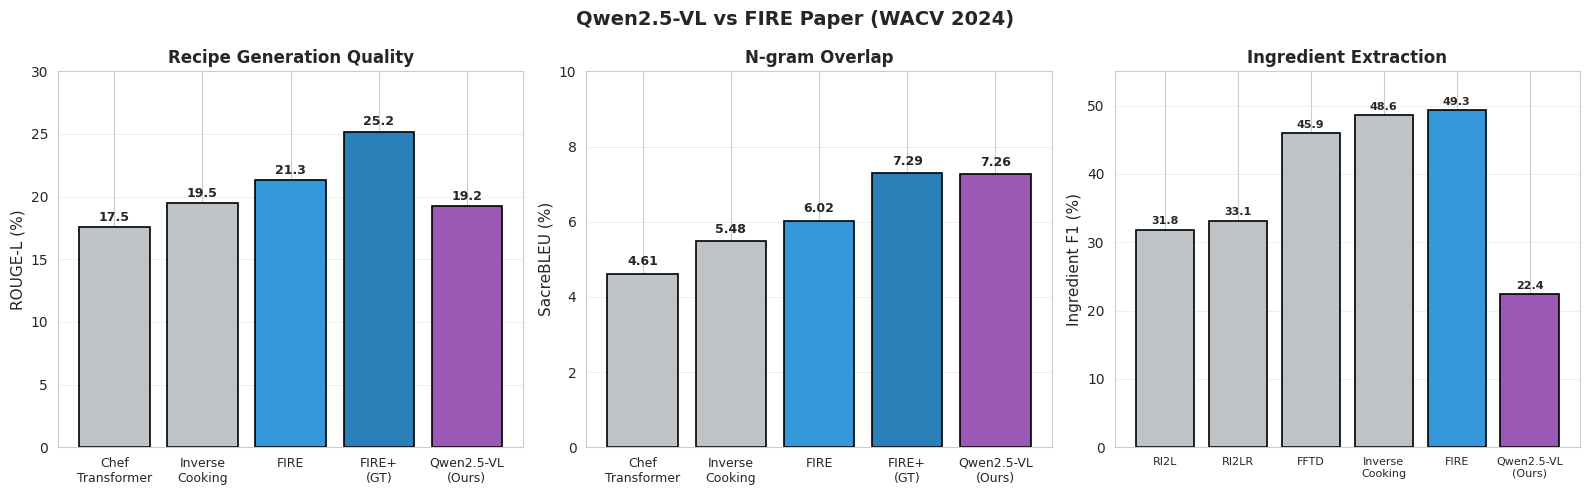


COMPARISON: Qwen2.5-VL vs FIRE (WACV 2024)
Metric             FIRE         Ours         Diff        
----------------------------------------------------------------------
ROUGE-L            21.29        19.22        -2.07
SacreBLEU          6.02         7.26         +1.24
Ingredient F1      49.27        22.39        -26.88
----------------------------------------------------------------------

Note: FIRE trained on 259K+ samples; Qwen2.5-VL fine-tuned with LoRA on ~1K samples.


In [ ]:
# Visualize evaluation metrics with comparison to FIRE paper (WACV 2024)
# Reference: Chhikara et al., "FIRE: Food Image to REcipe generation", WACV 2024
# Paper: https://arxiv.org/abs/2308.14391

# FIRE paper results from Table 1 and Table 2 (Recipe1M dataset)
fire_paper_results = {
    'recipe_generation': {
        'Chef Transformer': {'SacreBLEU': 4.61, 'ROUGE-L': 17.54},
        'InverseCooking': {'SacreBLEU': 5.48, 'ROUGE-L': 19.47},
        'FIRE': {'SacreBLEU': 6.02, 'ROUGE-L': 21.29},
        'FIRE+ (GT)': {'SacreBLEU': 7.29, 'ROUGE-L': 25.17},
    },
    'ingredient_extraction': {
        'RI2L': {'F1': 31.83},
        'RI2LR': {'F1': 33.13},
        'FFTD': {'F1': 45.94},
        'InverseCooking': {'F1': 48.61},
        'FIRE': {'F1': 49.27},
    }
}

if 'all_metrics' in globals() and all_metrics is not None and len(all_metrics['rouge_l']) > 0:
    print("Generating FIRE paper comparison...")
    print("Reference: Chhikara et al., WACV 2024")
    print("Paper: https://arxiv.org/abs/2308.14391\n")

    # Calculate metrics (convert to percentages)
    our_rouge_l = np.mean(all_metrics['rouge_l']) * 100
    our_bleu = np.mean(all_metrics['bleu']) * 100
    our_ingredient_f1 = np.mean(all_metrics['ingredient_f1']) * 100

    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Qwen2.5-VL vs FIRE Paper (WACV 2024)', fontsize=14, fontweight='bold')

    # Color scheme - Purple for Qwen
    gray = '#bdc3c7'
    fire_blue = '#3498db'
    fire_dark = '#2980b9'
    ours_purple = '#9b59b6'

    # ========== Plot 1: ROUGE-L ==========
    ax1 = axes[0]
    models = ['Chef\nTransformer', 'Inverse\nCooking', 'FIRE', 'FIRE+\n(GT)', 'Qwen2.5-VL\n(Ours)']
    rouge_scores = [17.54, 19.47, 21.29, 25.17, our_rouge_l]
    colors = [gray, gray, fire_blue, fire_dark, ours_purple]

    bars1 = ax1.bar(models, rouge_scores, color=colors, edgecolor='black', linewidth=1.2)
    ax1.set_ylabel('ROUGE-L (%)', fontsize=11)
    ax1.set_title('Recipe Generation Quality', fontsize=12, fontweight='bold')
    ax1.set_ylim(0, 30)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.tick_params(axis='x', labelsize=9)

    for bar, val in zip(bars1, rouge_scores):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # ========== Plot 2: SacreBLEU ==========
    ax2 = axes[1]
    bleu_scores = [4.61, 5.48, 6.02, 7.29, our_bleu]

    bars2 = ax2.bar(models, bleu_scores, color=colors, edgecolor='black', linewidth=1.2)
    ax2.set_ylabel('SacreBLEU (%)', fontsize=11)
    ax2.set_title('N-gram Overlap', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 10)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.tick_params(axis='x', labelsize=9)

    for bar, val in zip(bars2, bleu_scores):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.15,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # ========== Plot 3: Ingredient F1 ==========
    ax3 = axes[2]
    f1_models = ['RI2L', 'RI2LR', 'FFTD', 'Inverse\nCooking', 'FIRE', 'Qwen2.5-VL\n(Ours)']
    f1_scores = [31.83, 33.13, 45.94, 48.61, 49.27, our_ingredient_f1]
    f1_colors = [gray, gray, gray, gray, fire_blue, ours_purple]

    bars3 = ax3.bar(f1_models, f1_scores, color=f1_colors, edgecolor='black', linewidth=1.2)
    ax3.set_ylabel('Ingredient F1 (%)', fontsize=11)
    ax3.set_title('Ingredient Extraction', fontsize=12, fontweight='bold')
    ax3.set_ylim(0, max(55, our_ingredient_f1 + 5))
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.tick_params(axis='x', labelsize=8)

    for bar, val in zip(bars3, f1_scores):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    plt.tight_layout()

    # Save plot
    plt.savefig("qwen_vs_fire.png", dpi=300, bbox_inches='tight', facecolor='white')
    print("Saved: qwen_vs_fire.png")
    plt.show()

    # Print comparison table
    print("\n" + "=" * 70)
    print("COMPARISON: Qwen2.5-VL vs FIRE (WACV 2024)")
    print("=" * 70)
    print(f"{'Metric':<18} {'FIRE':<12} {'Ours':<12} {'Diff':<12}")
    print("-" * 70)
    print(f"{'ROUGE-L':<18} {21.29:<12.2f} {our_rouge_l:<12.2f} {our_rouge_l - 21.29:+.2f}")
    print(f"{'SacreBLEU':<18} {6.02:<12.2f} {our_bleu:<12.2f} {our_bleu - 6.02:+.2f}")
    print(f"{'Ingredient F1':<18} {49.27:<12.2f} {our_ingredient_f1:<12.2f} {our_ingredient_f1 - 49.27:+.2f}")
    print("-" * 70)
    print("\nNote: FIRE trained on 259K+ samples; Qwen2.5-VL fine-tuned with LoRA on ~1K samples.")
    print("=" * 70)

else:
    print("No metrics available. Run evaluation cell first.")

## 12. Load Saved Model (if training was completed earlier)

In [ ]:
# Load saved LoRA model for inference
model_path = "./qwen_recipe_model_final"
base_model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

if os.path.exists(model_path) and os.path.exists(os.path.join(model_path, "adapter_config.json")):
    print(f"Loading LoRA adapter from {model_path}...")
    
    from peft import PeftModel
    
    # Load base model
    base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        base_model_name,
        torch_dtype=torch.float16,
        device_map={"": 0},
        low_cpu_mem_usage=True,
    )
    
    # Load LoRA adapter
    qwen_model = PeftModel.from_pretrained(base_model, model_path)
    qwen_model = qwen_model.merge_and_unload()  # Merge for faster inference
    
    qwen_processor = AutoProcessor.from_pretrained(model_path)
    qwen_model.eval()
    
    print("✓ LoRA model loaded and merged successfully!")
elif os.path.exists(model_path) and os.path.exists(os.path.join(model_path, "config.json")):
    # Fallback: load as regular model
    print(f"Loading model from {model_path}...")
    qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_path,
        torch_dtype=torch.float16,
        device_map={"": 0},
        low_cpu_mem_usage=True,
    )
    qwen_processor = AutoProcessor.from_pretrained(model_path)
    qwen_model.eval()
    print("✓ Model loaded successfully!")
else:
    print("⚠️ Saved model not found. Using base model or run training first.")

Loading LoRA adapter from ./qwen_recipe_model_final...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.39it/s]


✓ LoRA model loaded and merged successfully!


## 13. Recipe Generation Function

In [ ]:
def generate_recipe(image_path, model, processor, max_new_tokens=2048):
    """Generate a recipe from a food image."""
    
    # Load image
    image = Image.open(image_path).convert('RGB')
    
    # Create prompt
    prompt_text = "Generate a detailed cooking recipe from this food image. Include ingredients, instructions, cooking times, and temperatures."
    
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt_text}
            ]
        }
    ]
    
    # Process inputs
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )
    
    # Move to device
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Get token IDs
    pad_token_id = processor.tokenizer.pad_token_id or processor.tokenizer.eos_token_id
    eos_token_id = processor.tokenizer.eos_token_id
    
    # Generate
    model.eval()
    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=pad_token_id,
            eos_token_id=eos_token_id,
            repetition_penalty=1.1,
        )
    
    # Decode only the newly generated tokens
    input_length = inputs['input_ids'].shape[1]
    generated_tokens = generated_ids[0][input_length:]
    
    # Decode
    recipe = processor.decode(generated_tokens, skip_special_tokens=True)
    
    return {
        'recipe': recipe,
        'image_path': image_path
    }

print("✓ Recipe generation function defined!")

✓ Recipe generation function defined!


## 14. Test Recipe Generation

In [ ]:
# Test recipe generation on a few samples
if processed_data:
    print("Testing recipe generation...")
    print("=" * 60)
    
    test_samples = random.sample(processed_data, min(3, len(processed_data)))
    
    for i, sample in enumerate(test_samples, 1):
        print(f"\n{'='*60}")
        print(f"Test {i}/{len(test_samples)}")
        print(f"Original Recipe: {sample['title']}")
        print(f"Image: {sample['image_path']}")
        print(f"\n{'='*60}")
        
        try:
            result = generate_recipe(
                sample['image_path'],
                qwen_model,
                qwen_processor,
                max_new_tokens=1024
            )
            
            print("\nGenerated Recipe:")
            print(result['recipe'])
            
        except Exception as e:
            print(f"\n⚠️ Error generating recipe: {e}")
            import traceback
            traceback.print_exc()
            
else:
    print("⚠️ No processed data available for testing")

Testing recipe generation...

Test 1/3
Original Recipe: Grand Marnier Soufflés
Image: food_images/Food Images/grand-marnier-souffles-351569.jpg


Generated Recipe:
RECIPE: Classic Soufflé

INGREDIENTS:
['2 tablespoons all-purpose flour', '1 cup whole milk (at room temperature)', '2 large eggs', '1/4 teaspoon salt', '1 tablespoon unsalted butter, at room temperature, divided']

INSTRUCTIONS:
Whisk together the flour, 3 tablespoons of the milk, and salt in a bowl until smooth.
In another bowl, beat the eggs with a fork or whisk until frothy. Pour into the bowl with the flour mixture and whisk just until combined. Do not overmix! Fold gently to incorporate as much air as possible while keeping the egg yolks intact.
Heat the remaining 1 tablespoon of milk in a small saucepan over medium heat until it begins to simmer. Add the butter to the milk and whisk to combine. Remove the pan from the heat and stir into the egg mixture along with any solids that have settled out of the egg yolk mixtur

## 15. Visualization of Training Metrics

✓ Training plots saved to 'training_metrics.png'


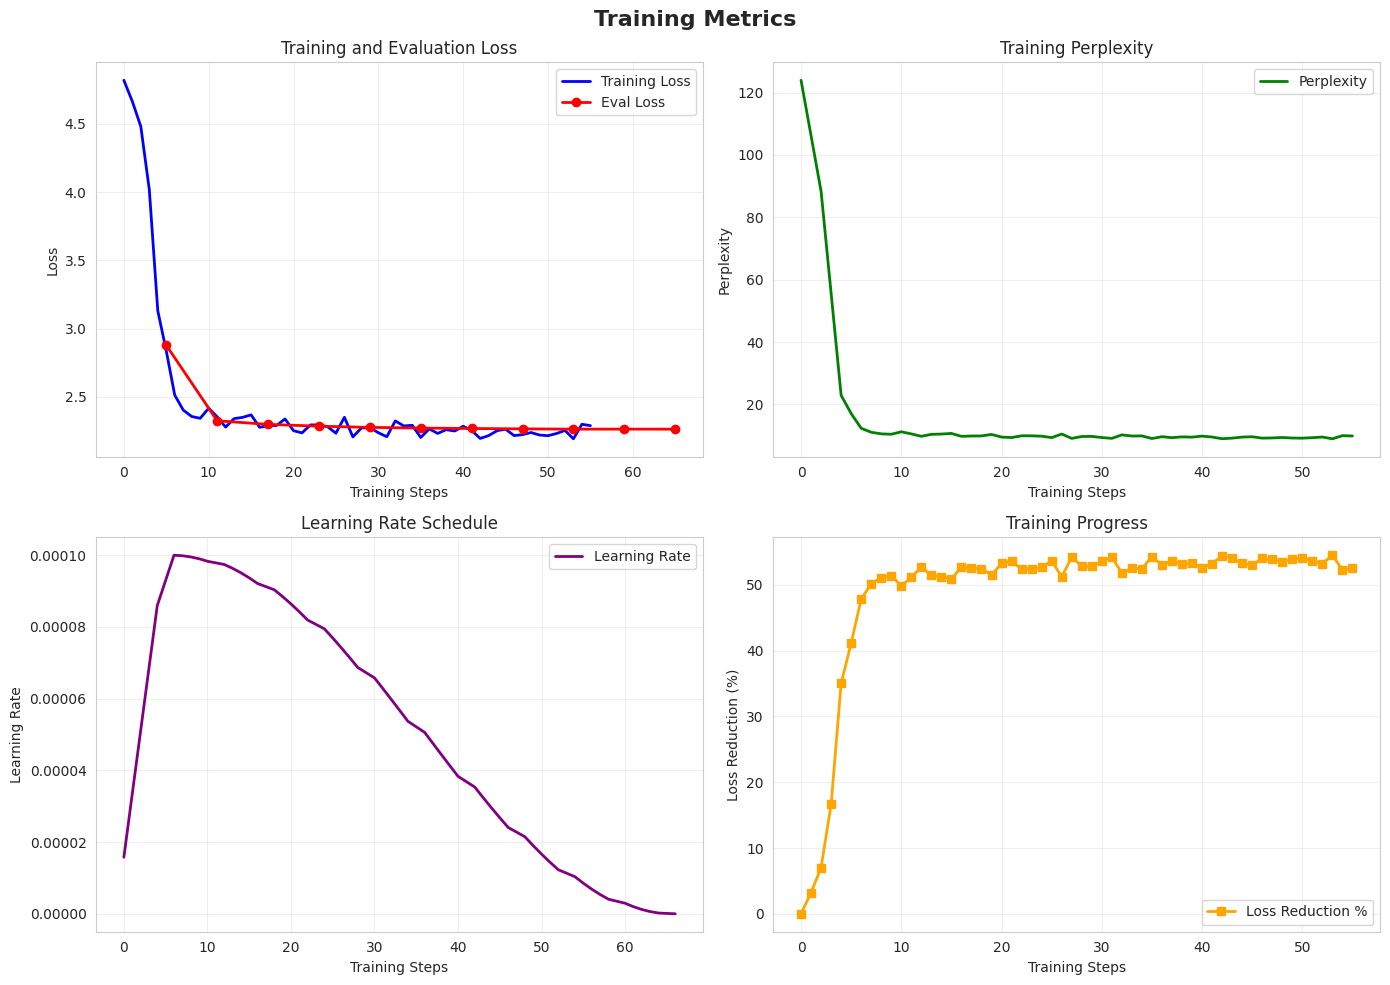

In [ ]:
# Plot training metrics if available
if 'trainer' in globals() and hasattr(trainer, 'state'):
    try:
        log_history = trainer.state.log_history
        
        train_losses = [entry['loss'] for entry in log_history if 'loss' in entry]
        eval_losses = [entry['eval_loss'] for entry in log_history if 'eval_loss' in entry]
        learning_rates = [entry['learning_rate'] for entry in log_history if 'learning_rate' in entry]
        
        if train_losses:
            fig, axes = plt.subplots(2, 2, figsize=(14, 10))
            fig.suptitle('Training Metrics', fontsize=16, fontweight='bold')
            
            # Training Loss
            steps = range(len(train_losses))
            axes[0, 0].plot(steps, train_losses, 'b-', label='Training Loss', linewidth=2)
            if eval_losses:
                eval_steps = [i for i, entry in enumerate(log_history) if 'eval_loss' in entry]
                if len(eval_steps) == len(eval_losses):
                    axes[0, 0].plot(eval_steps, eval_losses, 'r-', label='Eval Loss', linewidth=2, marker='o')
            axes[0, 0].set_xlabel('Training Steps')
            axes[0, 0].set_ylabel('Loss')
            axes[0, 0].set_title('Training and Evaluation Loss')
            axes[0, 0].legend()
            axes[0, 0].grid(True, alpha=0.3)
            
            # Perplexity
            perplexities = [np.exp(loss) for loss in train_losses]
            axes[0, 1].plot(steps, perplexities, 'g-', label='Perplexity', linewidth=2)
            axes[0, 1].set_xlabel('Training Steps')
            axes[0, 1].set_ylabel('Perplexity')
            axes[0, 1].set_title('Training Perplexity')
            axes[0, 1].legend()
            axes[0, 1].grid(True, alpha=0.3)
            
            # Learning Rate
            if learning_rates:
                lr_steps = [i for i, entry in enumerate(log_history) if 'learning_rate' in entry]
                if lr_steps:
                    axes[1, 0].plot(lr_steps, learning_rates, 'purple', label='Learning Rate', linewidth=2)
            axes[1, 0].set_xlabel('Training Steps')
            axes[1, 0].set_ylabel('Learning Rate')
            axes[1, 0].set_title('Learning Rate Schedule')
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)
            
            # Loss Reduction
            if len(train_losses) > 1:
                initial_loss = train_losses[0]
                loss_reductions = [((initial_loss - loss) / initial_loss) * 100 for loss in train_losses]
                axes[1, 1].plot(steps, loss_reductions, 'orange', label='Loss Reduction %', linewidth=2, marker='s')
                axes[1, 1].set_xlabel('Training Steps')
                axes[1, 1].set_ylabel('Loss Reduction (%)')
                axes[1, 1].set_title('Training Progress')
                axes[1, 1].legend()
                axes[1, 1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
            print("✓ Training plots saved to 'training_metrics.png'")
            plt.show()
        else:
            print("⚠️ No training history available")
    except Exception as e:
        print(f"⚠️ Could not plot metrics: {e}")
else:
    print("⚠️ No training history available (training not run yet or log file not found)")

## 16. Gradio Web Interface


In [ ]:
import gradio as gr

def gradio_generate_recipe(image):
    """
    Wrapper function for Gradio interface
    """
    if image is None:
        return "⚠️ Please upload an image."
    
    try:
        # Ensure PIL Image
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        
        if image.mode != 'RGB':
            image = image.convert('RGB')
        
        # Save temp image path for compatibility with generate_recipe function
        temp_path = "temp_food_image.jpg"
        image.save(temp_path)
        
        # Generate recipe using the defined function
        result = generate_recipe(
            temp_path,
            qwen_model,
            qwen_processor,
            max_new_tokens=2048
        )
        
        # Format output
        recipe_text = result.get('recipe', str(result)) if isinstance(result, dict) else result
        
        output = f"""{'=' * 60}
{recipe_text}
{'=' * 60}
NOTE: This recipe was generated by AI and may require refinement.
Please verify ingredients and instructions before cooking.
"""
        
        # Cleanup
        if os.path.exists(temp_path):
            os.remove(temp_path)
        
        return output
        
    except Exception as e:
        import traceback
        error_msg = f"❌ Error: {str(e)}"
        print(error_msg)
        print(traceback.format_exc())
        return error_msg


# Create Gradio interface
with gr.Blocks(title="Food Recipe Generator (Qwen2.5-VL-3B)", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🍽️ Food to Recipe Generator
    ### Powered by Qwen2.5-VL-3B-Instruct
    
    Upload a food image and get a detailed AI-generated recipe with:
    - 📋 Complete ingredient list
    - ⏱️ Preparation and cooking time estimates
    - 🌡️ Cooking temperature and methods
    - 📝 Step-by-step instructions
    """)
    
    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(
                label="Upload Food Image",
                type="pil",
                height=400
            )
            generate_btn = gr.Button(
                "🚀 Generate Recipe",
                variant="primary",
                size="lg"
            )
            
            gr.Markdown("""
            ### Tips:
            - Upload clear food images
            - Works best with single dishes
            - Recipes are generated using fine-tuned Qwen2.5-VL-3B
            - Powered by state-of-the-art vision-language model
            """)
        
        with gr.Column(scale=1):
            recipe_output = gr.Textbox(
                label="Generated Recipe",
                lines=25,
                max_lines=30,
                placeholder="Your recipe will appear here...",
                show_copy_button=True
            )
    
    # Connect function
    generate_btn.click(
        fn=gradio_generate_recipe,
        inputs=image_input,
        outputs=recipe_output
    )
    
    image_input.upload(
        fn=gradio_generate_recipe,
        inputs=image_input,
        outputs=recipe_output
    )
    
    gr.Markdown("""
    ---
    **Note**: Recipes are AI-generated and may need refinement.
    
    Built with [Qwen2.5-VL-3B-Instruct](https://huggingface.co/Qwen/Qwen2.5-VL-3B-Instruct) + [Gradio](https://gradio.app)
    """)

print("✓ Gradio interface created!")
print("\nTo launch the interface, run:")
print("  demo.launch(share=True)  # For public link")
print("  demo.launch()            # For local access")


✓ Gradio interface created!

To launch the interface, run:
  demo.launch(share=True)  # For public link
  demo.launch()            # For local access


### Launch the Web Interface


In [43]:
# Launch Gradio interface
# Uncomment one of the options below:

# Option 1: Local access only (http://localhost:7860)
demo.launch(server_name="0.0.0.0", server_port=7860)

# Option 2: Create public link (share=True)
# demo.launch(share=True)

# Option 3: Both local and public
# demo.launch(server_name="0.0.0.0", server_port=7860, share=True)


OSError: Cannot find empty port in range: 7860-7860. You can specify a different port by setting the GRADIO_SERVER_PORT environment variable or passing the `server_port` parameter to `launch()`.